In [1]:
import dagshub
import mlflow
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import joblib, os, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
df = pd.read_csv("../data/drought_dataset.csv")
df.head()

,lat,lon,observation_time,temp_c,humidity,precipitation_mm,wind_speed,pressure,hour,day,month,temp_rolling_mean,humidity_rolling_mean,precip_rolling_sum,wind_rolling_mean,cum_rain_3days,drought_label
0,13.743409,-15.785126,2022-01-01 00:00:00+00:00,24.8,22.0,0.0,11.3,1012.5,0,1,1,24.800000,22.000000,0.0,11.300000,0.0,1
1,13.743409,-15.785126,2022-01-01 01:00:00+00:00,23.8,20.0,0.0,12.3,1012.3,1,1,1,24.300000,21.000000,0.0,11.800000,0.0,1
2,13.743409,-15.785126,2022-01-01 02:00:00+00:00,23.6,19.0,0.0,12.0,1012.1,2,1,1,24.066667,20.333333,0.0,11.866667,0.0,1
3,13.743409,-15.785126,2022-01-01 03:00:00+00:00,23.3,19.0,0.0,12.5,1011.6,3,1,1,23.875000,20.000000,0.0,12.025000,0.0,1
4,13.743409,-15.785126,2022-01-01 04:00:00+00:00,23.2,19.0,0.0,13.0,1011.0,4,1,1,23.740000,19.800000,0.0,12.220000,0.0,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78912 entries, 0 to 78911
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lat                    78912 non-null  float64
 1   lon                    78912 non-null  float64
 2   observation_time       78912 non-null  object 
 3   temp_c                 78912 non-null  float64
 4   humidity               78912 non-null  float64
 5   precipitation_mm       78912 non-null  float64
 6   wind_speed             78912 non-null  float64
 7   pressure               78912 non-null  float64
 8   hour                   78912 non-null  int64  
 9   day                    78912 non-null  int64  
 10  month                  78912 non-null  int64  
 11  temp_rolling_mean      78912 non-null  float64
 12  humidity_rolling_mean  78912 non-null  float64
 13  precip_rolling_sum     78912 non-null  float64
 14  wind_rolling_mean      78912 non-null  float64
 15  cu

### RandomForestClassifier

Initialized MLflow to track repo "IbrahimFaye/weather-agri"

Repository IbrahimFaye/weather-agri initialized!

✅ Drought Model — Accuracy: 1.000 | F1: 1.000
F1 Score - Cross-validation: 1.000 (+/- 0.000)
🔗 Résultats visibles sur DagsHub
🏃 View run classy-mink-908 at: https://dagshub.com/IbrahimFaye/weather-agri.mlflow/#/experiments/3/runs/a050e2674fc54e8f9993c1c7bf6cf58f
🧪 View experiment at: https://dagshub.com/IbrahimFaye/weather-agri.mlflow/#/experiments/3


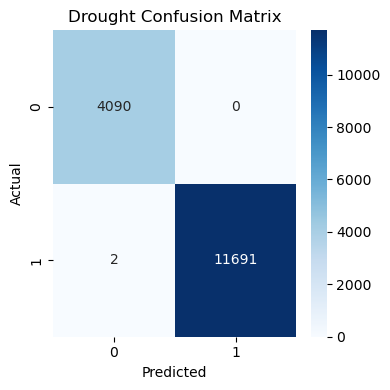

In [5]:
from sklearn.model_selection import cross_val_score


dagshub.init(repo_owner='IbrahimFaye', repo_name='weather-agri', mlflow=True)

def main():
    mlflow.set_experiment("drought_forecast")

    df = pd.read_csv("../data/drought_dataset.csv")

    df = df.dropna(subset=["drought_label"])
    df["drought_label"] = df["drought_label"].astype(int)

    exclude = ["observation_time", "rain_next_hour", "drought_label"]
    X = df.drop(columns=exclude, errors="ignore").select_dtypes(include=["number"])
    y = df["drought_label"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    with mlflow.start_run():
        model = RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            class_weight="balanced",
            random_state=42
        )
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)

        mlflow.log_metrics({"accuracy": acc, "f1_score": f1})
        mlflow.log_params({"n_estimators": 200, "max_depth": 10})

        os.makedirs("artifacts", exist_ok=True)
        joblib.dump(model, "artifacts/secheresse_model.pkl")
        mlflow.log_artifact("artifacts/secheresse_model.pkl", artifact_path="model")

        importance = dict(zip(X.columns, np.round(model.feature_importances_, 4)))
        mlflow.log_dict(importance, "feature_importance.json")

        #  Matrice de confusion
        cm = confusion_matrix(y_test, preds)
        plt.figure(figsize=(4, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Drought Confusion Matrix")
        plt.tight_layout()
        plt.savefig("artifacts/drought_confusion_matrix.png")
        mlflow.log_artifact("artifacts/drought_confusion_matrix.png", artifact_path="plots")

        print(f"✅ Drought Model — Accuracy: {acc:.3f} | F1: {f1:.3f}")


        # Validation croisée
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
        print(f"F1 Score - Cross-validation: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
        mlflow.log_metric("cv_f1_mean", cv_scores.mean())
        print("🔗 Résultats visibles sur DagsHub")

if __name__ == "__main__":
    main()


### 

In [15]:
print(df["drought_label"].value_counts(normalize=True))

drought_label
1    0.742207
0    0.257793
Name: proportion, dtype: float64


In [17]:
df.corr(numeric_only=True)["drought_label"].sort_values(ascending=False)


drought_label            1.000000
wind_rolling_mean        0.316270
wind_speed               0.284171
lat                      0.139067
lon                      0.026397
temp_rolling_mean        0.017287
temp_c                   0.016017
hour                     0.000450
day                     -0.055350
pressure                -0.107028
precipitation_mm        -0.193710
month                   -0.274261
precip_rolling_sum      -0.316609
humidity                -0.554079
humidity_rolling_mean   -0.574110
cum_rain_3days          -0.658263
Name: drought_label, dtype: float64